## Setup, Synthetic Data Generation, and Visualization

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

### SYNTHETIC DATA GENERATOR (LHC SIMULATOR)

In [3]:
def generate_dataset(n_events=500, signal_prob=0.05):
    print(f"📦 Generating dataset with {n_events} events...")
    dataset = []

    for i in range(n_events):
        # BACKGROUND: 300 random hits (pile-up noise)
        n_back = 300
        hits = np.random.uniform(0, 100, (n_back, 2))
        # Background energy: exponential distribution (many low-energy hits)
        energies = np.random.exponential(10, n_back)

        is_signal = np.random.random() < signal_prob
        if is_signal:
            # SIGNAL: A dense cluster of hits (decay vertex)
            n_sig = 40
            center = np.random.uniform(30, 70, 2)
            sig_hits = np.random.normal(center, 0.5, (n_sig, 2))
            # Signal energy: gaussian distribution (higher energy hits)
            sig_energies = np.random.normal(10, 10, n_sig)

            hits = np.vstack([hits, sig_hits])
            energies = np.concatenate([energies, sig_energies])

        dataset.append({
            'id': i,
            'hits': hits,
            'energies': energies,
            'is_signal': is_signal,
        })
    print("✅ Dataset ready.")
    return dataset

### Generate and visualise the data

📦 Generating dataset with 10000 events...
✅ Dataset ready.


/tmp/ipykernel_6819/1067876200.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 1].legend()


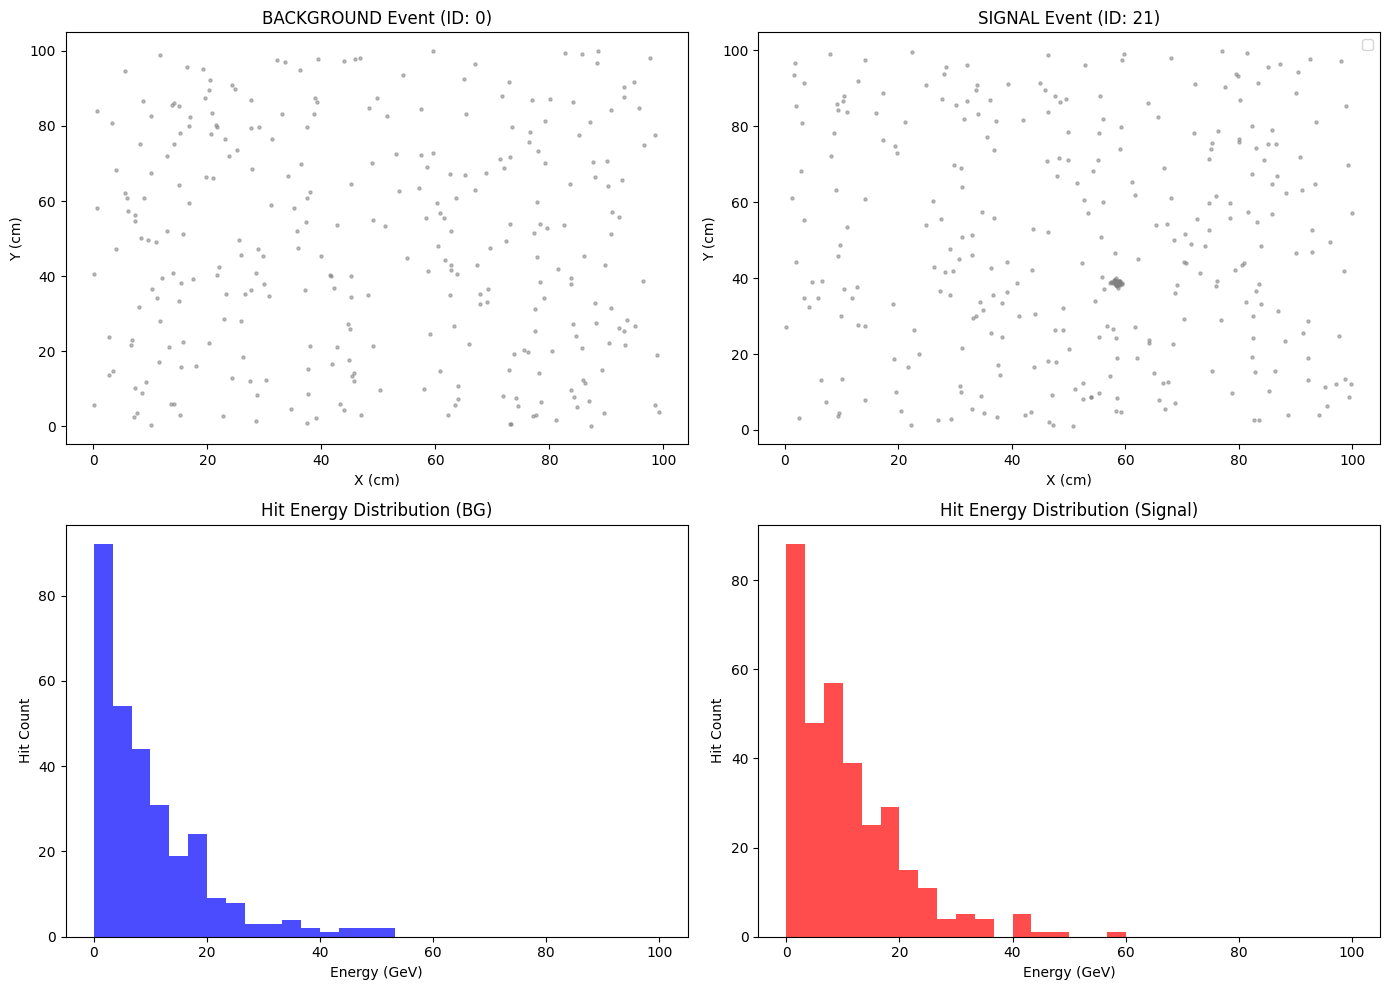

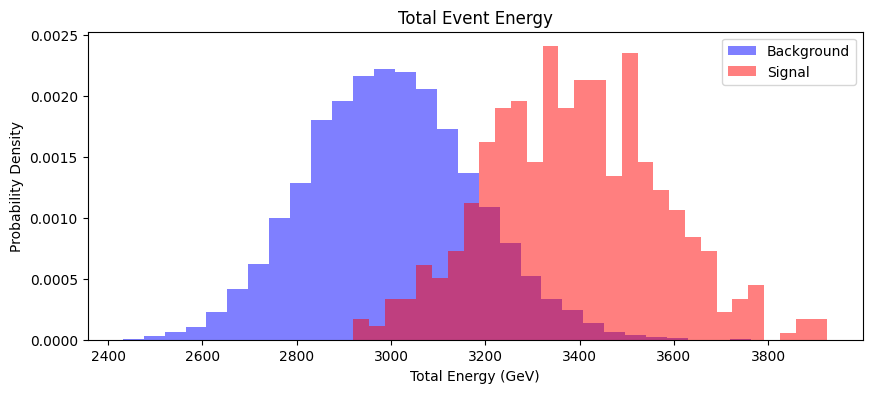

In [4]:
# Generate the data
N_EVENTS = 10000
events = generate_dataset(N_EVENTS)

# =============================================================================
# 2. DATA VISUALIZATION (UNDERSTANDING THE PHYSICS)
# =============================================================================
# Find one example of each for visualization
event_bg = next(e for e in events if not e['is_signal'])
event_sig = next(e for e in events if e['is_signal'])

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# A. Spatial Visualization (Detector Hits)
axs[0, 0].scatter(event_bg['hits'][:, 0], event_bg['hits'][:, 1], s=5, color='gray', alpha=0.5)
axs[0, 0].set_title(f"BACKGROUND Event (ID: {event_bg['id']})")
axs[0, 0].set_xlabel("X (cm)")
axs[0, 0].set_ylabel("Y (cm)")

axs[0, 1].scatter(event_sig['hits'][:, 0], event_sig['hits'][:, 1], s=5, color='gray', alpha=0.5)
axs[0, 1].set_title(f"SIGNAL Event (ID: {event_sig['id']})")
axs[0, 1].set_xlabel("X (cm)")
axs[0, 1].set_ylabel("Y (cm)")
axs[0, 1].legend()

# B. Hit Energy Distribution
axs[1, 0].hist(event_bg['energies'], bins=30, range=(0, 100), color='blue', alpha=0.7, label='Background')
axs[1, 0].set_title("Hit Energy Distribution (BG)")
axs[1, 0].set_xlabel("Energy (GeV)")
axs[1, 0].set_ylabel("Hit Count")

axs[1, 1].hist(event_sig['energies'], bins=30, range=(0, 100), color='red', alpha=0.7, label='Signal')
axs[1, 1].set_title("Hit Energy Distribution (Signal)")
axs[1, 1].set_xlabel("Energy (GeV)")
axs[1, 1].set_ylabel("Hit Count")

plt.tight_layout()
plt.show()

# C. Total Event Energy
energies_total_bg = [np.sum(e['energies']) for e in events if not e['is_signal']]
energies_total_sig = [np.sum(e['energies']) for e in events if e['is_signal']]

plt.figure(figsize=(10, 4))
plt.hist(energies_total_bg, bins=30, color='blue', alpha=0.5, label='Background', density=True)
plt.hist(energies_total_sig, bins=30, color='red', alpha=0.5, label='Signal', density=True)
plt.title("Total Event Energy")
plt.xlabel("Total Energy (GeV)")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

### THROUGHPUT BENCHMARK
We will use this function to evaluate if our trigger algorithm is fast enough for the LHC input rate.

In [10]:
def run_rta_simulation_single_stage(events, trigger_func, rate_hz=40000000):
    """
    Evaluates if a single trigger algorithm can handle a specific data rate.
    Default rate: 40 MHz (LHC collision rate).
    """
    # Unit adaptation logic
    if rate_hz >= 1e6:
        rate_str = f"{rate_hz/1e6:.1f} MHz"
    elif rate_hz >= 1e3:
        rate_str = f"{rate_hz/1e3:.1f} kHz"
    else:
        rate_str = f"{rate_hz:.0f} Hz"

    print(f"\n--- RTA Stress Test ---")
    print(f"Target Data Rate: {rate_str}")
    print(f"Time budget per event: {(1/rate_hz)*1e6:.3f} microseconds (µs)")

    # 1. Benchmark: Measure execution time
    # We use more repetitions for a better average
    n_test = min(20, len(events))
    t_start = time.perf_counter()
    for i in range(n_test):
        trigger_func(events[i])
    t_end = time.perf_counter()

    t_proc = (t_end - t_start) / n_test
    max_rate_possible = 1.0 / t_proc

    # Format max rate units
    if max_rate_possible >= 1e6:
        max_rate_str = f"{max_rate_possible/1e6:.2f} MHz"
    elif max_rate_possible >= 1e3:
        max_rate_str = f"{max_rate_possible/1e3:.2f} kHz"
    else:
        max_rate_str = f"{max_rate_possible:.2f} Hz"

    print(f"⏱️ Your algorithm takes: {t_proc*1e6:.3f} microseconds per event.")
    print(f"🚀 Maximum possible rate with this code: {max_rate_str}")

    # 2. Simulation of Buffer at Target Rate
    # We'll simulate 500 events to see the occupancy trend
    max_buffer = 100
    dt_detector = 1.0 / rate_hz
    buffer_history = []
    current_buffer = 0
    lost = 0

    for _ in range(len(events)):
        current_buffer += 1 # New event arrives
        if current_buffer > max_buffer:
            lost += 1
            current_buffer = max_buffer

        # Process events during the interval dt_detector
        events_processed = dt_detector / t_proc
        current_buffer -= events_processed
        if current_buffer < 0: current_buffer = 0
        buffer_history.append(current_buffer)

    # 3. Results Visualization
    plt.figure(figsize=(10, 4))
    plt.plot(buffer_history, color='red' if lost > 0 else 'green')
    plt.axhline(y=max_buffer, color='black', linestyle='--', label="Buffer Limit")
    plt.title(f"Buffer Occupancy at {rate_str}")
    plt.ylabel("Events in Queue")
    plt.xlabel("Event Number")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    if lost > 0:
        factor = t_proc / (1/rate_hz)
        print(f"❌ DEAD TIME DETECTED: System lost {lost} events.")
        print(f"To run at {rate_str}, your code needs to be {factor:.1f}x faster!")
    else:
        print(f"✅ SUCCESS: Your algorithm can handle the {rate_str} input rate.")

### Physics Performance
Our trigger algorithms should be fast but also select the physics that we want! We need a trade-off between speed and physics performance, so for any trigger algorithm we should evaluate both.

This function allows to evaluate the physics performance in terms of:
- signal efficiency: fraction of signal events selected
- background rejection: fraction of background events rejected
- signal purity: fraction of signal events in total selected events

In [11]:
def evaluate_physics_performance(events, trigger_func):
    """
    Evaluates the signal efficiency and background rejection of a trigger.
    """
    total_sig = sum(1 for e in events if e['is_signal'])
    total_bg = sum(1 for e in events if not e['is_signal'])

    selected_sig = 0
    selected_bg = 0

    for e in events:
        passed = trigger_func(e)
        if passed:
            if e['is_signal']:
                selected_sig += 1
            else:
                selected_bg += 1

    sig_efficiency = (selected_sig / total_sig) * 100 if total_sig > 0 else 0
    bg_rejection = (1 - (selected_bg / total_bg)) * 100 if total_bg > 0 else 0
    purity = (selected_sig / (selected_sig + selected_bg)) * 100 if (selected_sig + selected_bg) > 0 else 0

    print(f"\n--- Physics Performance Evaluation ---")
    print(f"- Signal Efficiency: {sig_efficiency:.2f}% ({selected_sig}/{total_sig})")
    print(f"- Background Rejection: {bg_rejection:.2f}%")
    print(f"- Signal Purity in selected sample: {purity:.2f}%")

    if sig_efficiency < 80:
        print("⚠️ Warning: Low signal efficiency. You are losing too much physics!")
    if bg_rejection < 90:
        print("⚠️ Warning: Low background rejection. Your HLT/L1 is too 'loose'.")

### 1. CLASSICAL TRIGGER APPROACH: Simple HARDWARE Trigger

Exercise: define a simple (fast) selection to retain signal while rejecting ~90% of background using the hit energy.
1. Use the total energy of the event (sum of the energy of all the hits): find a threshold that separates them.
2. Estimate which fraction of the signal you retain to achieve a ~90% background rejection.

Such triggers are typically implemented on the hardware electronics, where very fast but simple calculations are possible. We emulate this here in a simple algorithm.

In [17]:
def l1_trigger(event):
    """
    Very fast filter based on total energy.
    Input: event dictionary with 'energies' array.
    """
    # YOUR CODE HERE:
    # calculate total energy of the event
    total_energy = np.sum(event['energies'])

    # Threshold choice: Look at the histograms from the visualization
    # to find a value that rejects ~90% of background.
    # Based on the 'Total Event Energy' plot, a threshold around 2500-2800 could reject most background.
    # Let's start with 2800 as a guess to achieve ~90% background rejection.
    threshold = 3300
    return total_energy > threshold

#### Evaluation
1. Speed


--- RTA Stress Test ---
Target Data Rate: 40.0 MHz
Time budget per event: 0.025 microseconds (µs)
⏱️ Your algorithm takes: 7.534 microseconds per event.
🚀 Maximum possible rate with this code: 132.74 kHz


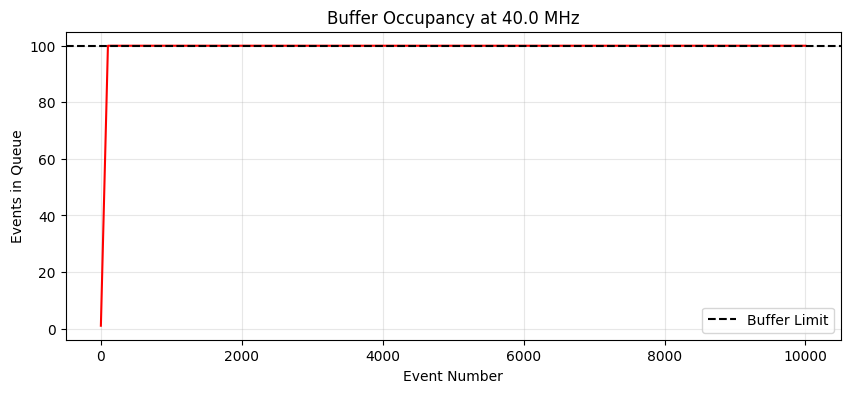

❌ DEAD TIME DETECTED: System lost 9900 events.
To run at 40.0 MHz, your code needs to be 301.3x faster!


In [18]:
input_rate=40e6 # 40 MHz - L1 handles the full LHC rate.
run_rta_simulation_single_stage(events, l1_trigger, rate_hz=input_rate)

Sadly, Python is way too slow to use it for the LHC trigger, even for this very simple algorithm!

Real LHC trigger systems use FPGAs (hardware/L1) and ultra-optimised C++ (HLT) to achieve the extremely low required latency (O(ns)).

For this exercicse, we'll use an input rate of 2 kHz instead as demonstrator.


--- RTA Stress Test ---
Target Data Rate: 2.0 kHz
Time budget per event: 500.000 microseconds (µs)
⏱️ Your algorithm takes: 9.292 microseconds per event.
🚀 Maximum possible rate with this code: 107.62 kHz


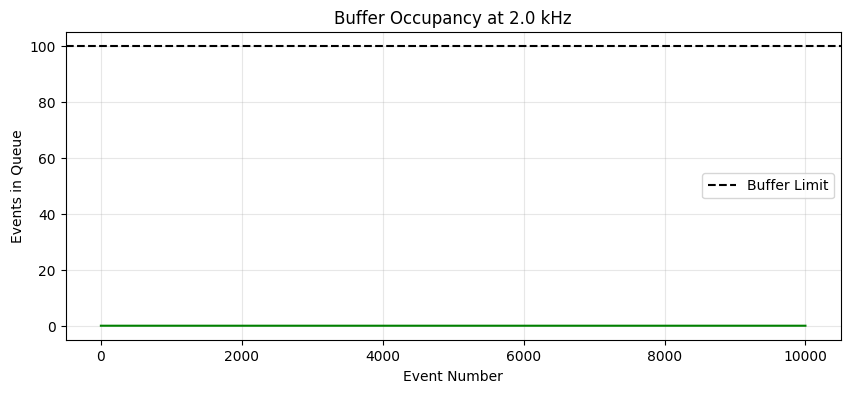

✅ SUCCESS: Your algorithm can handle the 2.0 kHz input rate.


In [19]:
input_rate=2e3 # 2 kHz - L1 handles the full LHC rate.
run_rta_simulation_single_stage(events, l1_trigger, rate_hz=input_rate)

2. Physics Performance

In [20]:
evaluate_physics_performance(events, l1_trigger)


--- Physics Performance Evaluation ---
- Signal Efficiency: 67.73% (361/533)
- Background Rejection: 95.31%
- Signal Purity in selected sample: 44.84%
⚠️ Warning: Low signal efficiency. You are losing too much physics!


**Question**: what do you conclude about this algorithm in terms of
- speed
- physics performance

### 2. COMPLEX TRIGGER APPROACH: High Level Trigger
Let's use a more sophisticated algorithm that can reject 90% of the background without loosing much signal.
We will look for clusters of hits in the x-y space, corresponding to events with signal.

Implement the following algorithm:
- For every hit 'i', check every hit 'j' in a nested loop.
- Calculate the Euclidean distance. If dist < 0.8, we count the pair.
- Trigger condition: if more than 15 close pairs are found, keep the event.

In [ ]:
# TASK 2: HLT Trigger (Complex, based on topology/vertexing)
# Aim to identify the dense cluster of hits.
def hlt_trigger(event):
    hits = event['hits']

    count = 0
    # YOUR CODE HERE: Implement a nested loop (O(N^2))
    # For every hit 'i', check every hit 'j'...
    # Calculate Euclidean distance. If dist < 0.8, count it.

    # ... nested loops


    # Trigger condition: if more than 15 close pairs are found, keep the event.
    return count > 15


Evaluation: let's start with physics performance.

Since this algorithm is quite slow, we evaluate it on 200 events only.

In [ ]:
events_hlt = generate_dataset(100)
evaluate_physics_performance(events_hlt, hlt_trigger)

Now let's check the speed. In classical triggers, HLT handles the reduced rate after L1 processing. So let's test it with a 10 Hz reduced input rate.

In [ ]:
input_rate=10 # 10 Hz - HLT typically handles the reduced rate after L1 processing.
run_rta_simulation_single_stage(events, hlt_trigger, rate_hz=input_rate)

Compare the achivable rate with the simple L1 trigger and the complex HLT trigger.

The difference is:
- L1: performs a sum -> $O(N)$ operations
- HLT: performs a vertexing/clustering search -> $O(N^2)$ or $O(N log N)$ operations

### 3. The RTA Challenge: Complex AND Fast trigger
**Goal**: Use advanced algorithms to achieve HLT precision at L1 speeds.

**Context**: Modern experiments use vectorization, parallelization, or specialized data structures to solve the $O(N^2)$ bottleneck

Let's first check if our naive HLT algorithm can run at the L1 speed:

In [ ]:
input_rate=2e3 # 2 kHz - We want HLT to handle the full LHC input rate so it should run as fast as L1 did in the past!
run_rta_simulation_single_stage(events, hlt_trigger, rate_hz=input_rate)

What happened? Our naive HLT algorithm is way too slow! Let's use advanced algorithms to speed it up.  

**Exercise**: use Spatial Trees (ckDTree from scipy.spatial) to perform the clustering.

In [ ]:
# TASK 3: Optimize the HLT using cKDTree (Spatial Indexing)
from scipy.spatial import cKDTree

def hlt_trigger_optimized(event):
    """
    High-performance filter using a K-Dimensional Tree.
    This reduces the search from O(N^2) to O(N log N).
    """
    hits = event['hits']

    # YOUR CODE HERE:
    # 1. Build the tree: tree = cKDTree(hits)
    # 2. Query pairs within distance r=0.8
    # 3. Return True if number of pairs > 15

    return ...

EVALUATION

Let's first check this algorithm still gives a good physics performance.

In [ ]:
evaluate_physics_performance(events_hlt, hlt_trigger_fast)

Let's now check it's speed

In [ ]:
# EXECUTE SIMULATION 3
input_rate = 2e3 # 2 kHz
run_rta_simulation_single_stage(events, hlt_trigger, rate_hz=input_rate)

### Conclusions: Real-Time Analysis (RTA)

#### 1. The Physics vs. Computing Trade-off
In Experimental Physics, the "best" algorithm is not just the one with the highest precision, but the one that fits within the **time budget**.
* **Simple Triggers (L1-style):** Are extremely fast but have poor selectivity, leading to "dirty" datasets with high background contamination.
* **Complex Algorithms (HLT-style):** Provide excellent signal purity but can be computationally expensive.

#### 2. The Danger of Dead Time
We observed that if an algorithm's processing time $t_{proc}$ exceeds the interval between incoming events ($1/rate$), the system's buffer fills up.
* Once the buffer is full, the detector is still active, but the DAQ (Data Acquisition) system is "blind."
* **Dead Time** is the ultimate enemy: an event not processed in real-time is a piece of physics lost forever.

#### 3. Algorithm Complexity Matters ($O(N^2)$ vs. $O(N \log N)$)
* The **Naive approach** (nested loops) scales quadratically. As detector occupancy (pile-up) increases, these algorithms collapse exponentially.
* **RTA strategies** involve using specialized data structures (like **Spatial KD-Trees**) and vectorization to keep the processing time linear or logarithmic, allowing us to maintain high physics performance even at high rates.

#### 4. Why Python is not used for L1
Even our most simple Python code struggled to reach the **40 MHz** rate of the LHC (25 ns window).
* Real-world RTA requires high-performance hardware/software approach:
    1. **Custom Hardware (FPGAs/ASICs)** for the fastest, simplest decisions at L1. ATLAS and CMS at the LHC use this approach.
    2. **High-Performance Computing (C++/CUDA in CPU/GPU)** for complex real-time reconstruction. LHCb at the LHC now uses a full-software based trigger implemented in GPUs and processing the 40 MHz LHC input rate in real time!

> **Final Thought:** Real-Time Analysis is the art of making the most scientifically significant decision in the shortest possible time. Efficiency is not just a technical detail; it is a requirement for discovery.

### Extension or Home work

Increase the input_rate in the simulation (e.g., 5000, 10000...).

At what point does even the Optimized HLT fail?

How would you fix it?